In [1]:
#কোন customer আগামীতে service ছেড়ে যেতে পারে?"
#Churn = Yes → customer চলে গেছে
# Churn = No → customer আছে

In [9]:
import pandas as pd

df = pd.read_csv("data/WA_Fn-UseC_-Telco-Customer-Churn.csv")

print(df.head())

   customerID  gender  SeniorCitizen Partner Dependents  tenure PhoneService  \
0  7590-VHVEG  Female              0     Yes         No       1           No   
1  5575-GNVDE    Male              0      No         No      34          Yes   
2  3668-QPYBK    Male              0      No         No       2          Yes   
3  7795-CFOCW    Male              0      No         No      45           No   
4  9237-HQITU  Female              0      No         No       2          Yes   

      MultipleLines InternetService OnlineSecurity  ... DeviceProtection  \
0  No phone service             DSL             No  ...               No   
1                No             DSL            Yes  ...              Yes   
2                No             DSL            Yes  ...               No   
3  No phone service             DSL            Yes  ...              Yes   
4                No     Fiber optic             No  ...               No   

  TechSupport StreamingTV StreamingMovies        Contract Pape

In [10]:
#Data Understanding
# Dataset কেমন?

print(df.shape)

(7043, 21)


In [11]:
#Columns finding

print(df.columns)

Index(['customerID', 'gender', 'SeniorCitizen', 'Partner', 'Dependents',
       'tenure', 'PhoneService', 'MultipleLines', 'InternetService',
       'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport',
       'StreamingTV', 'StreamingMovies', 'Contract', 'PaperlessBilling',
       'PaymentMethod', 'MonthlyCharges', 'TotalCharges', 'Churn'],
      dtype='object')


In [12]:
#Missing Values Check

print(df.isnull().sum())

customerID          0
gender              0
SeniorCitizen       0
Partner             0
Dependents          0
tenure              0
PhoneService        0
MultipleLines       0
InternetService     0
OnlineSecurity      0
OnlineBackup        0
DeviceProtection    0
TechSupport         0
StreamingTV         0
StreamingMovies     0
Contract            0
PaperlessBilling    0
PaymentMethod       0
MonthlyCharges      0
TotalCharges        0
Churn               0
dtype: int64


In [17]:
# Exploratory Data Analysis (EDA)

#কতজন churn করেছে?

print(df["Churn"].value_counts())

No     5174
Yes    1869
Name: Churn, dtype: int64


In [18]:
#Percentage বের করা
df["Churn"].value_counts(normalize=True)*100

No     73.463013
Yes    26.536987
Name: Churn, dtype: float64

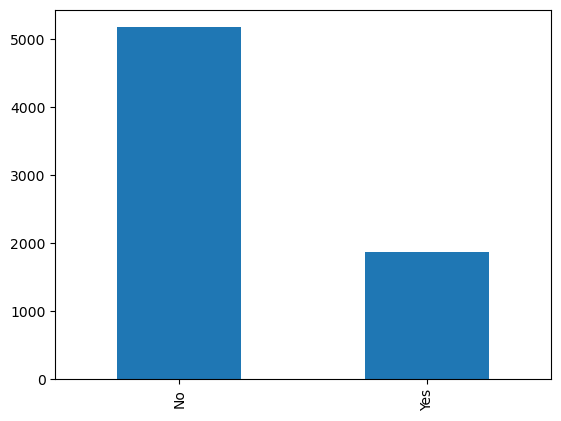

In [19]:
#Visualization

import matplotlib.pyplot as plt

df["Churn"].value_counts().plot(kind="bar")

plt.show()

In [21]:
# Business Insight

# Month-to-month customer বেশি churn করছে
# Two Year contract customer কম churn করছে

df.groupby("Contract")["Churn"].value_counts()

Contract        Churn
Month-to-month  No       2220
                Yes      1655
One year        No       1307
                Yes       166
Two year        No       1647
                Yes        48
Name: Churn, dtype: int64

In [22]:
#Feature Engineering (ML)
# Machine Learning text বুঝে না।

from sklearn.preprocessing import LabelEncoder

le = LabelEncoder()

df["Contract"] = le.fit_transform(df["Contract"])

In [23]:
# X এবং y তৈরি (Target আলাদা করো।)

X = df.drop("Churn", axis=1)

y = df["Churn"]

In [24]:
# Train/Test Split

from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

In [29]:
# Model Training
#Logistic Regression 

from sklearn.linear_model import LogisticRegression

model = LogisticRegression()

model.fit(X_train, y_train)

C:\Users\shimu\anaconda3\Lib\site-packages\sklearn\linear_model\_logistic.py:460: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. of ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


LogisticRegression()

In [30]:
#Prediction
pred = model.predict(X_test)

In [31]:
#Accuracy

from sklearn.metrics import accuracy_score

acc = accuracy_score(y_test, pred)

print(acc)

0.8161816891412349


In [33]:
#Confusion Matrix

from sklearn.metrics import confusion_matrix

print(confusion_matrix(y_test, pred))

[[917 119]
 [140 233]]


In [35]:
from sklearn.metrics import classification_report

print(classification_report(y_test, pred))

              precision    recall  f1-score   support

           0       0.87      0.89      0.88      1036
           1       0.66      0.62      0.64       373

    accuracy                           0.82      1409
   macro avg       0.76      0.75      0.76      1409
weighted avg       0.81      0.82      0.81      1409



In [ ]:
# Random Forest Classifier

In [53]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

# ১. মডেল অবজেক্ট তৈরি এবং ট্রেইন করা
rf_model = RandomForestClassifier(n_estimators=100, random_state=42)
rf_model.fit(X_train, y_train)

# ২. প্রেডিকশন করা
rf_pred = rf_model.predict(X_test)

# ৩. ইভালুয়েশন
print("--- Random Forest Results ---")
print(f"Accuracy: {accuracy_score(y_test, rf_pred)}")
print("\nConfusion Matrix:")
print(confusion_matrix(y_test, rf_pred))
print("\nClassification Report:")
print(classification_report(y_test, rf_pred))

--- Random Forest Results ---
Accuracy: 0.7792760823278921

Confusion Matrix:
[[912 124]
 [187 186]]

Classification Report:
              precision    recall  f1-score   support

           0       0.83      0.88      0.85      1036
           1       0.60      0.50      0.54       373

    accuracy                           0.78      1409
   macro avg       0.71      0.69      0.70      1409
weighted avg       0.77      0.78      0.77      1409



In [ ]:
# XGBoost Classifier (Extreme Gradient Boosting)

In [54]:
from xgboost import XGBClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

# ১. মডেল অবজেক্ট তৈরি এবং ট্রেইন করা
xgb_model = XGBClassifier(n_estimators=100, learning_rate=0.1, random_state=42)
xgb_model.fit(X_train, y_train)

# ২. প্রেডিকশন করা
xgb_pred = xgb_model.predict(X_test)

# ৩. ইভালুয়েশন
print("--- XGBoost Results ---")
print(f"Accuracy: {accuracy_score(y_test, xgb_pred)}")
print("\nConfusion Matrix:")
print(confusion_matrix(y_test, xgb_pred))
print("\nClassification Report:")
print(classification_report(y_test, xgb_pred))

--- XGBoost Results ---
Accuracy: 0.8097941802696949

Confusion Matrix:
[[939  97]
 [171 202]]

Classification Report:
              precision    recall  f1-score   support

           0       0.85      0.91      0.88      1036
           1       0.68      0.54      0.60       373

    accuracy                           0.81      1409
   macro avg       0.76      0.72      0.74      1409
weighted avg       0.80      0.81      0.80      1409



In [ ]:
# তিনটি মডেলের পারফরম্যান্স একসাথে তুলনা করার জন্য একটি চমৎকার ভিজ্যুয়াল ড্যাশবোর্ড

C:\Users\shimu\anaconda3\Lib\site-packages\seaborn\utils.py:80: UserWarning: Glyph 128640 (\N{ROCKET}) missing from current font.
  fig.canvas.draw()
C:\Users\shimu\anaconda3\Lib\site-packages\IPython\core\pylabtools.py:152: UserWarning: Glyph 128640 (\N{ROCKET}) missing from current font.
  fig.canvas.print_figure(bytes_io, **kw)


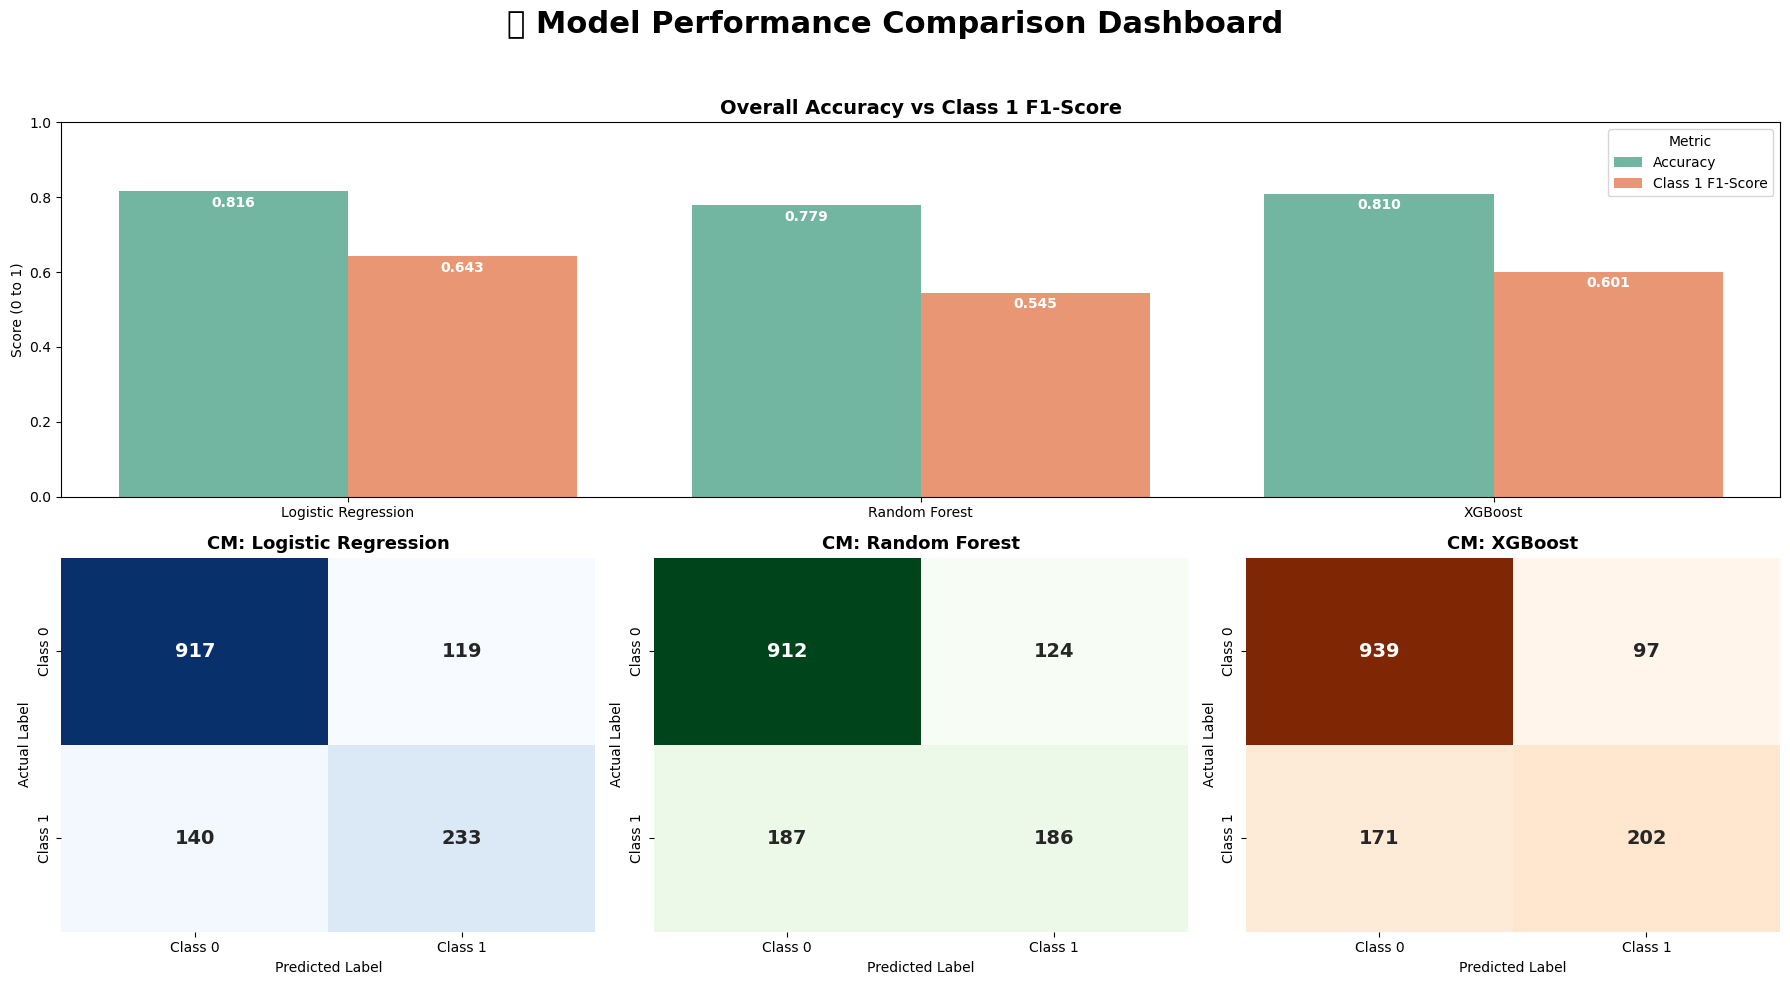

In [55]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
from sklearn.metrics import accuracy_score, f1_score, confusion_matrix

# ===============================
# ৩টি মডেলের প্রেডিকশন এখানে সেট 
# ===============================
# (আপনার কোডের ভেরিয়েবলের নামের সাথে এগুলো মিলিয়ে নিন)
y_preds = {
    'Logistic Regression': pred,     # আপনার প্রথম মডেলের প্রেডিকশন ভেরিয়েবল
    'Random Forest': rf_pred,        # দ্বিতীয় মডেলের প্রেডিকশন ভেরিয়েবল
    'XGBoost': xgb_pred              # তৃতীয় মডেলের প্রেডিকশন ভেরিয়েবল
}

# মেত্রিক্স ক্যালকুলেট করার জন্য খালি লিস্ট
models_metrics = []
conf_matrices = {}

for name, pred_val in y_preds.items():
    acc = accuracy_score(y_test, pred_val)
    # যেহেতু Class 1 এর পারফরম্যান্স আমাদের মূল টার্গেট, তাই pos_label=1 দেওয়া হয়েছে
    f1_c1 = f1_score(y_test, pred_val, pos_label=1) 
    
    models_metrics.append({'Model': name, 'Accuracy': acc, 'Class 1 F1-Score': f1_c1})
    conf_matrices[name] = confusion_matrix(y_test, pred_val)

df_metrics = pd.DataFrame(models_metrics)

# ==========================================
# ২. ড্যাশবোর্ড প্লট করা (Visualization)
# ==========================================
fig = plt.figure(figsize=(18, 10))
plt.suptitle("🚀 Model Performance Comparison Dashboard", fontsize=22, fontweight='bold', y=0.98)

# গ্রাফ ১: Accuracy ও F1-Score এর তুলনামূলক বার চার্ট
ax1 = plt.subplot2grid((2, 3), (0, 0), colspan=3)
df_melted = pd.melt(df_metrics, id_vars='Model', var_name='Metric', value_name='Score')
sns.barplot(x='Model', y='Score', hue='Metric', data=df_melted, palette='Set2', ax=ax1)
ax1.set_title("Overall Accuracy vs Class 1 F1-Score", fontsize=14, fontweight='bold')
ax1.set_ylim(0, 1.0)
ax1.set_ylabel("Score (0 to 1)")
ax1.set_xlabel("")
for p in ax1.patches:
    ax1.annotate(f"{p.get_height():.3f}", (p.get_x() + p.get_width() / 2., p.get_height() - 0.05),
                ha='center', va='center', xytext=(0, 5), textcoords='offset points', fontweight='bold', color='white')

# গ্রাফ ২, ৩, ৪: তিনটি মডেলের Confusion Matrix পাশাপাশি
plot_index = 0
colors_maps = ['Blues', 'Greens', 'Oranges']

for name, matrix in conf_matrices.items():
    ax = plt.subplot2grid((2, 3), (1, plot_index))
    sns.heatmap(matrix, annot=True, fmt='d', cmap=colors_maps[plot_index], cbar=False,
                xticklabels=['Class 0', 'Class 1'], yticklabels=['Class 0', 'Class 1'], ax=ax, annot_kws={"size": 14, "weight": "bold"})
    ax.set_title(f"CM: {name}", fontsize=13, fontweight='bold')
    ax.set_ylabel('Actual Label')
    ax.set_xlabel('Predicted Label')
    plot_index += 1

plt.tight_layout(rect=[0, 0, 1, 0.95])
plt.show()